16 Dec 2025

#### Preliminaries

In [1]:
#filename
file_name = "2d_v4_pos_current_v4"

#basic_operations
import os
import math
import pickle
from datetime import date

#exploratory_data_analysis
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from numpy.fft import fft, fftfreq

#data_generation 
from scipy.interpolate import splprep, splev

#deep_learning
import torch
import torch.nn as nn
from complexPyTorch.complexLayers import ComplexLinear, ComplexReLU
from torch.utils.data import TensorDataset, DataLoader, random_split

#gpu_usage
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist

#random_seed
torch.manual_seed(42)
np.random.seed(42)

# Constants
epsilon = 1e-10

#math
from sympy import diff

In [2]:
# Check if CUDA is available
print("Is CUDA available?", torch.cuda.is_available())

# Total number of GPUs available
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {num_gpus}")

# List all GPU names
for i in range(num_gpus):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


Is CUDA available? False
Number of GPUs available: 0


In [3]:
# Simulation Parameters
today = "26th_jun_2026"

dt = 0.01
total_time = 5
time_series = np.arange(0, total_time, dt)
total_time_steps = len(time_series)
print(today)

26th_jun_2026


#### Loading Data

In [4]:
data_path = '/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/zagent_data'

train_visual_limb_data_file = "13_dec_train_visual_limb_data.pkl"
train_traj_data_file = "13_dec_train_traj_data.pkl"

test_visual_limb_data_file = "13_dec_test_visual_limb_data.pkl"
test_traj_data_file = "13_dec_test_traj_data.pkl"

with open(f'{data_path}/{train_visual_limb_data_file}', 'rb') as f:
    train_visual_limb_data = pickle.load(f)

with open(f'{data_path}/{train_traj_data_file}', 'rb') as f:
    train_trajectory_data = pickle.load(f)

with open(f'{data_path}/{test_visual_limb_data_file}', 'rb') as f:
    test_visual_limb_data = pickle.load(f)

with open(f'{data_path}/{test_traj_data_file}', 'rb') as f:
    test_trajectory_data = pickle.load(f)

In [5]:
print(train_visual_limb_data.shape)
print(train_trajectory_data.shape)
# 1 to 20 - Visual Cue
# 21 to 24 - Limb Oscillations (UFL, UFR, UHR, UHL)
# 25 - Curvature

print(test_visual_limb_data.shape)
print(test_trajectory_data.shape)
# 0 - X position
# 1 - Y position
# 2 - HD angle
# 3 - HD cos vector
# 4 - HD sin vector

(500, 1000, 87)
(500, 1000, 5)
(50, 1000, 87)
(50, 1000, 5)


In [6]:
# Considering only 500 timesteps for training faster
train_visual_limb_data = train_visual_limb_data[:, :500, :]
train_trajectory_data = train_trajectory_data[:, :500, :]

test_visual_limb_data = test_visual_limb_data[:, :500, :]
test_trajectory_data = test_trajectory_data[:, :500, :]

In [7]:
initial_pos_start = 0
initial_pos_end = 2
visual_start = initial_pos_end
n_visual = 80  # Now just 80 landmarks (1 value per landmark: inverse distance)
visual_end = visual_start + n_visual
limb_osc_start = visual_end
n_limb_osc = 4
limb_osc_end = limb_osc_start + n_limb_osc
curvature_start = limb_osc_end
curvature_end = curvature_start + 1

n_pos = 2
n_hd_angle = 1
n_hd_vec = 2

def build_io_dicts(visual_limb_data, trajectory_data, n_visual=80):
    
    N, T, F = visual_limb_data.shape
    inputs = {}

    inputs["initial_pos"] = visual_limb_data[:, :, initial_pos_start:initial_pos_end]            # (N, T, 2)
    # visual cues: now just inverse distances (1/d) for each landmark

    n_visual = min(n_visual, F)
    inputs["visual_cue"] = visual_limb_data[:, :, visual_start:visual_end]            # (N, T, n_visual)
    # limb oscillations (next up to 4 channels)

    limb_start = n_visual+2
    limb_end = min(limb_start + n_limb_osc, F)
    inputs["limb_osc"] = visual_limb_data[:, :, limb_osc_start:limb_osc_end]    # (N, T, <=4)

    # curvature 
    inputs["curvature"] = visual_limb_data[:, :, curvature_start:curvature_end]  # (N, T, 1)

    # Outputs
    outputs = {}
    D = trajectory_data.shape[2]

    # position (x,y)
    outputs["pos"] = trajectory_data[:, :, :2]                          # (N, T, 2)

    # hd angle if present (single scalar per timestep)
    outputs["hd_angle"] = trajectory_data[:, :, 2:3]                # (N, T, 1)


    outputs["hd_cos"] = trajectory_data[:, :, 3:4]
    outputs["hd_sin"] = trajectory_data[:, :, 4:5]
    outputs["hd_vec"] = np.concatenate((outputs["hd_cos"], outputs["hd_sin"]), axis=-1)  # (N, T, 2)

    return inputs, outputs

# Build dicts and show shapes
train_inputs, train_outputs = build_io_dicts(train_visual_limb_data, train_trajectory_data)
print("Inputs:", {k: v.shape for k, v in train_inputs.items()})
print("Outputs:", {k: v.shape for k, v in train_outputs.items()})

test_inputs, test_outputs = build_io_dicts(test_visual_limb_data, test_trajectory_data)
print("Test Inputs:", {k: v.shape for k, v in test_inputs.items()})
print("Test Outputs:", {k: v.shape for k, v in test_outputs.items()})

Inputs: {'initial_pos': (500, 500, 2), 'visual_cue': (500, 500, 80), 'limb_osc': (500, 500, 4), 'curvature': (500, 500, 1)}
Outputs: {'pos': (500, 500, 2), 'hd_angle': (500, 500, 1), 'hd_cos': (500, 500, 1), 'hd_sin': (500, 500, 1), 'hd_vec': (500, 500, 2)}
Test Inputs: {'initial_pos': (50, 500, 2), 'visual_cue': (50, 500, 80), 'limb_osc': (50, 500, 4), 'curvature': (50, 500, 1)}
Test Outputs: {'pos': (50, 500, 2), 'hd_angle': (50, 500, 1), 'hd_cos': (50, 500, 1), 'hd_sin': (50, 500, 1), 'hd_vec': (50, 500, 2)}


In [8]:
traj_index = 0
time_index = 0

print("Initial Position:", train_inputs["initial_pos"][traj_index, time_index])
print("################")
print("Visual Cue:", train_inputs["visual_cue"][traj_index, time_index])
print("################")
print("Limb Oscillations:", train_inputs["limb_osc"][traj_index, time_index])
print("################")
print("Curvature:", train_inputs["curvature"][traj_index, time_index])
print("################")
print("Position:", train_outputs["pos"][traj_index, time_index])
print("################")
print("HD Angles:", train_outputs["hd_angle"][traj_index, time_index])
print("################")
print("HD Vector:", train_outputs["hd_vec"][traj_index, time_index])

Initial Position: [0.24377216 0.26929272]
################
Visual Cue: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         1.85534167 1.71228182 1.58781111
 1.47890174 1.38304973 1.29820096 1.32281625 1.34279275 1.35740638
 1.36608922 1.36848831 1.36450422 1.35430169 1.33829188 1.31708741
 1.2914412  1.26217997 1.2301414  1.19612348 1.16084945 1.12494671
 1.08893895 1.05324817 1.01820207 0.98404568 0.9509539  0.98283201
 1.01551878 1.04880369 1.08240759 1.11597228 1.14905488 1.18112469
 1.211568   1.23970282 1.26480436 1.2861433  1.30303359 1.31488681
 1.32126498 1.32192361 1.31683731 1.30620182 1.29041421 1.27003312
 1.24572706 1.32305288 1.40977573 1.50750506 1.61815786 1.74399054
 1.88759184 2.05178642 2.23933601 2.45223331 2.69024158 2.94821858
 3.2120378  0.         0.         0.         0.         0.
 0.         0.        ]
################
Limb Oscillations: [0.00000000e+00 7.1502

In [9]:
# Clockwise from bottom-left corner

def build_wall_landmarks(n_per_wall = 19):
    pos = np.linspace(0.05, 0.95, n_per_wall)
    landmarks = []

    landmarks.append((0.0, 0.0))
    for y in pos: landmarks.append((0.0, y))
    landmarks.append((0.0, 1.0))
    for x in pos: landmarks.append((x, 1.0))
    landmarks.append((1.0, 1.0))
    for y in reversed(pos): landmarks.append((1.0, y))
    landmarks.append((1.0, 0.0))
    for x in reversed(pos): landmarks.append((x, 0.0))
    
    return np.array(landmarks)

In [10]:
def plot_data(train_inputs, train_outputs, time_series, fov=np.pi, fov_radius=0.3):
    for i in range(5):
        traj_index = np.random.randint(0, len(train_inputs["visual_cue"]))
        landmarks = build_wall_landmarks()
        
        # Get data for current trajectory
        coordinate_data = train_outputs["pos"][traj_index]
        hd_vector_data = train_outputs["hd_vec"][traj_index]
        x_coords = coordinate_data[:, 0]
        y_coords = coordinate_data[:, 1]
        cos_thetas = hd_vector_data[:, 0]
        sin_thetas = hd_vector_data[:, 1]
        limb_oscillations = train_inputs["limb_osc"][traj_index]
        UFL_traj, UFR_traj, UHR_traj, UHL_traj = limb_oscillations.T
        k_traj = train_inputs["curvature"][traj_index]
        
        # Get visual cue data for current trajectory
        # Shape: [T, 80] where 80 landmarks, each has inverse distance (1/d)
        visual_cue = train_inputs["visual_cue"][traj_index]  # (T, 80)
        
        # Create a 2x2 grid
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [1, 1.5]})
        fig.suptitle(f"Trajectory {traj_index+1}", fontsize=16)
        

        # --- Top-left: Trajectory in grid with FOV ---
        # Pick a random timestep to show FOV
        t = np.random.randint(0, len(x_coords))
        xt, yt = x_coords[t], y_coords[t]
        head_vec = np.array([cos_thetas[t], sin_thetas[t]])
        
        # Extract visibility from visual cue at time t
        # visual_cue_inverse_dist[t, :] contains inverse distances for all 80 landmarks
        # If inverse distance > 0, landmark is visible
        inverse_dists_at_t = visual_cue[t, :]  # (80,)
        visible = inverse_dists_at_t > 0
        
        # Plot landmarks and trajectory
        axes[0, 0].scatter(landmarks[~visible, 0], landmarks[~visible, 1],
                          color='black', s=30, label='Not Visible', alpha=0.5)
        
        # For visible landmarks, use color to indicate inverse distance (fixed size)
        if np.any(visible):
            vis_inv_dists = inverse_dists_at_t[visible]
            scatter = axes[0, 0].scatter(landmarks[visible, 0], landmarks[visible, 1],
                              c=vis_inv_dists, s=30, cmap='hot', 
                              label='Visible', zorder=5, edgecolors='black', linewidths=0.5,
                              vmin=0, vmax=np.max(vis_inv_dists))
            # Add colorbar for inverse distance
            cbar = plt.colorbar(scatter, ax=axes[0, 0], fraction=0.046, pad=0.04)
            cbar.set_label('1/d (Inverse Distance)', rotation=270, labelpad=15, fontsize=9)
        
        axes[0, 0].plot(x_coords, y_coords, color='blue', label='Trajectory', linewidth=1.5)
        
        # Plot head direction arrows
        for j in range(0, len(x_coords), 50):  # every 50 steps
            axes[0, 0].arrow(x_coords[j], y_coords[j],
                    0.1 * cos_thetas[j], 0.1 * sin_thetas[j],
                    color='green', head_width=0.02, alpha=0.7)
            
        # Plot agent and FOV cone
        axes[0, 0].scatter(xt, yt, color='orange', s=100, zorder=10, edgecolors='black', linewidths=1)
        angle = math.atan2(head_vec[1], head_vec[0])
        left_angle = angle - fov/2
        right_angle = angle + fov/2
        
        # FOV cone edges
        axes[0, 0].plot([xt, xt + fov_radius * math.cos(left_angle)],
                       [yt, yt + fov_radius * math.sin(left_angle)],
                       'k--', alpha=0.5, linewidth=1)
        axes[0, 0].plot([xt, xt + fov_radius * math.cos(right_angle)],
                       [yt, yt + fov_radius * math.sin(right_angle)],
                       'k--', alpha=0.5, linewidth=1)
        
        # Shaded FOV cone
        theta = np.linspace(left_angle, right_angle, 30)
        axes[0, 0].fill(xt + fov_radius * np.cos(theta),
                       yt + fov_radius * np.sin(theta),
                       color='yellow', alpha=0.2)
        
        axes[0, 0].set_title(f'Trajectory & FOV at t={t} (timestep {t})')
        axes[0, 0].set_xlabel('X Position')
        axes[0, 0].set_ylabel('Y Position')
        axes[0, 0].set_xlim(0, 1)
        axes[0, 0].set_ylim(0, 1)
        axes[0, 0].grid(alpha=0.3)
        axes[0, 0].legend(loc='upper right', fontsize=8)
        axes[0, 0].set_aspect('equal')

        # --- Bottom-left: Position vs time ---
        axes[1, 0].plot(time_series, x_coords, label='X Position', color='orange', linewidth=1.5)
        axes[1, 0].plot(time_series, y_coords, label='Y Position', color='green', linewidth=1.5)
        axes[1, 0].axvline(time_series[t], color='red', linestyle=':', alpha=0.5, label=f'Current t={time_series[t]:.2f}s')
        axes[1, 0].set_title('Position vs Time')
        axes[1, 0].set_xlabel('Time (s)')
        axes[1, 0].set_ylabel('Position')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

        # --- Right column (span): Limb oscillations ---
        ax_right = axes[0, 1]
        ax_right.plot(time_series, UFL_traj[:len(time_series)], label='UFL', color='red', linewidth=1.5)
        ax_right.plot(time_series, UFR_traj[:len(time_series)], label='UFR', color='blue', linewidth=1.5)
        ax_right.plot(time_series, UHR_traj[:len(time_series)], label='UHR', color='green', linewidth=1.5)
        ax_right.plot(time_series, UHL_traj[:len(time_series)], label='UHL', color='purple', linewidth=1.5)
        ax_right.axvline(time_series[t], color='red', linestyle=':', alpha=0.5)
        
        ax_right.set_title(f'Limb Oscillations vs Time')
        ax_right.set_xlabel('Time (s)')
        ax_right.set_ylabel('Limb Angle (rad)')
        ax_right.legend()
        ax_right.grid(alpha=0.3)

        # --- Bottom-right: Curvature ---
        ax_bottom_right = axes[1, 1]
        ax_bottom_right.plot(time_series, k_traj[:len(time_series)], 
                           label='Curvature (k)', color='black', linestyle='-', linewidth=1.5, alpha=0.8)
        ax_bottom_right.axvline(time_series[t], color='red', linestyle=':', alpha=0.5)
        ax_bottom_right.axhline(0, color='gray', linestyle='--', alpha=0.3)
        ax_bottom_right.set_ylabel('Curvature (1/m)')
        ax_bottom_right.set_xlabel('Time (s)')
        ax_bottom_right.set_title('Path Curvature vs Time')
        ax_bottom_right.legend()
        ax_bottom_right.grid(alpha=0.3)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
        # Print visibility statistics
        num_visible = np.sum(visible)
        print(f"  Visible landmarks at t={t}: {num_visible}/80 ({num_visible/80*100:.1f}%)")

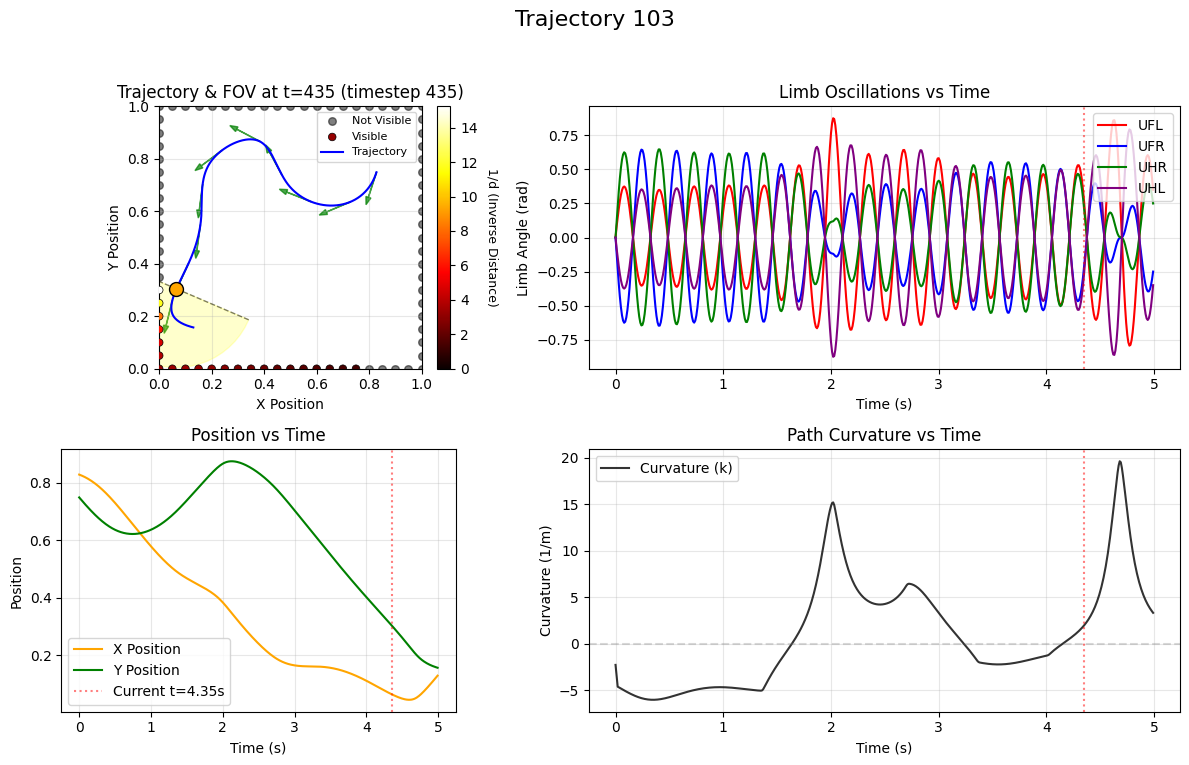

  Visible landmarks at t=435: 22/80 (27.5%)


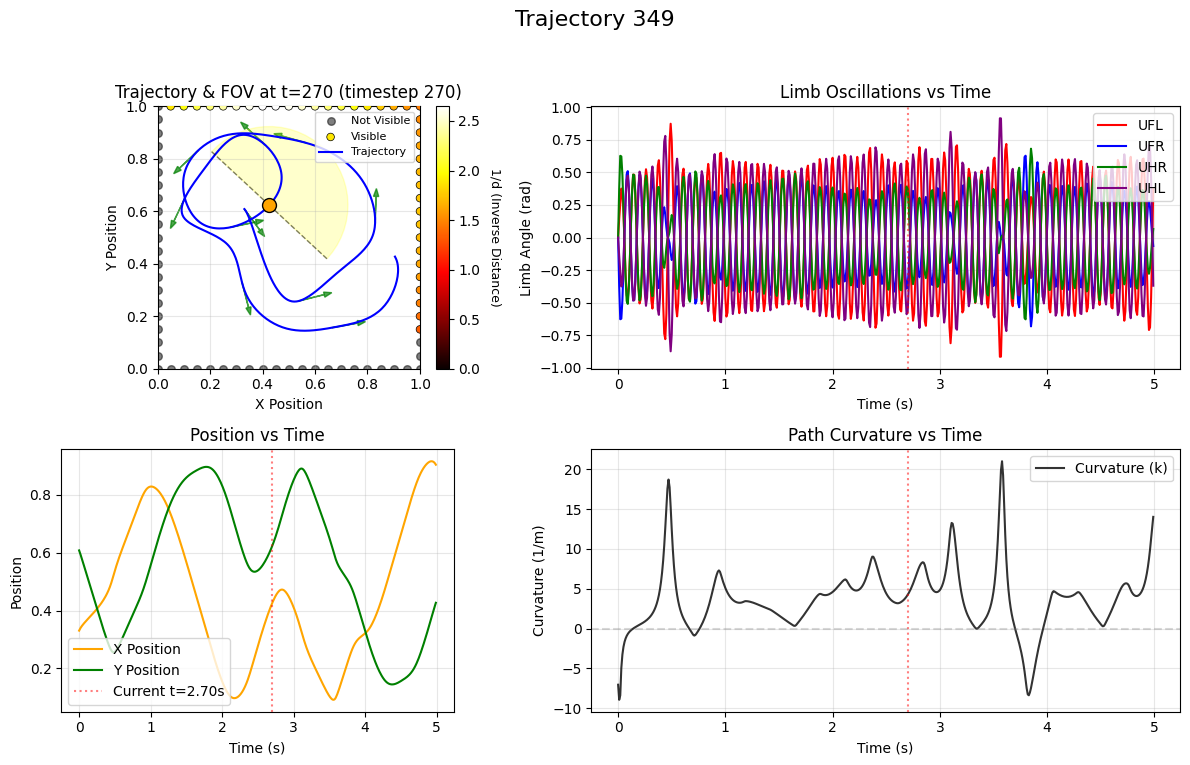

  Visible landmarks at t=270: 37/80 (46.2%)


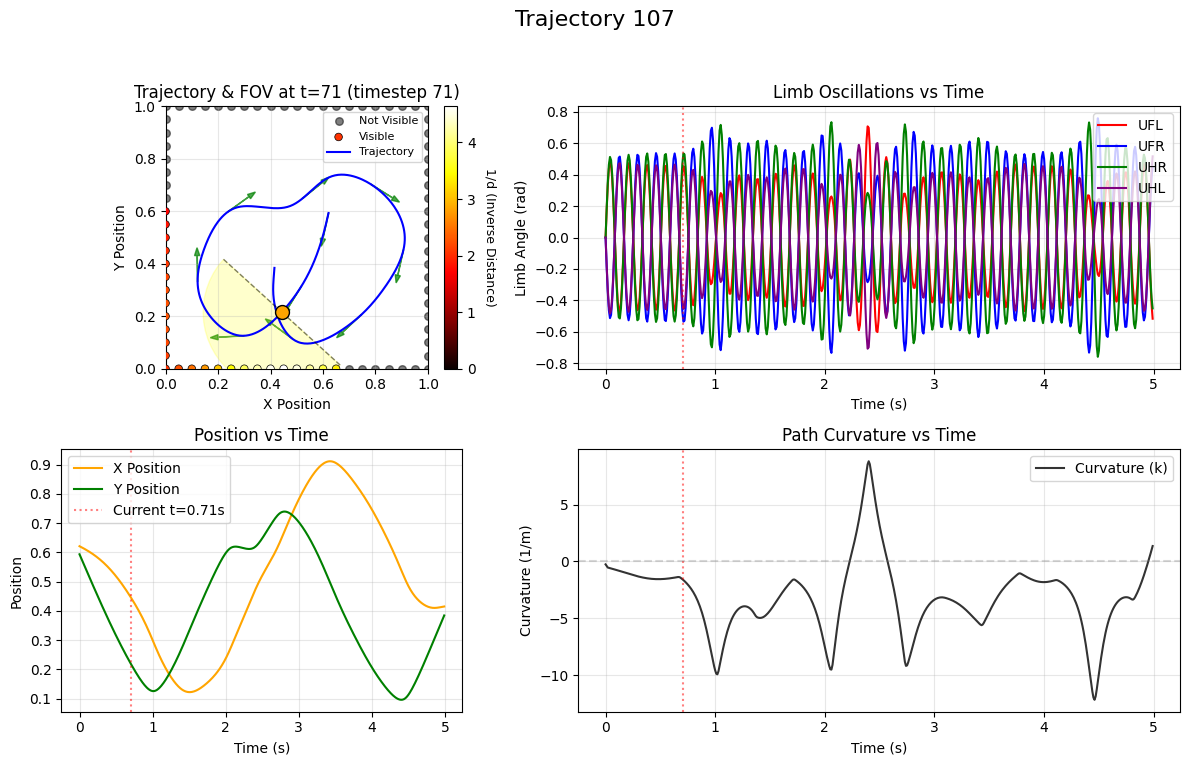

  Visible landmarks at t=71: 26/80 (32.5%)


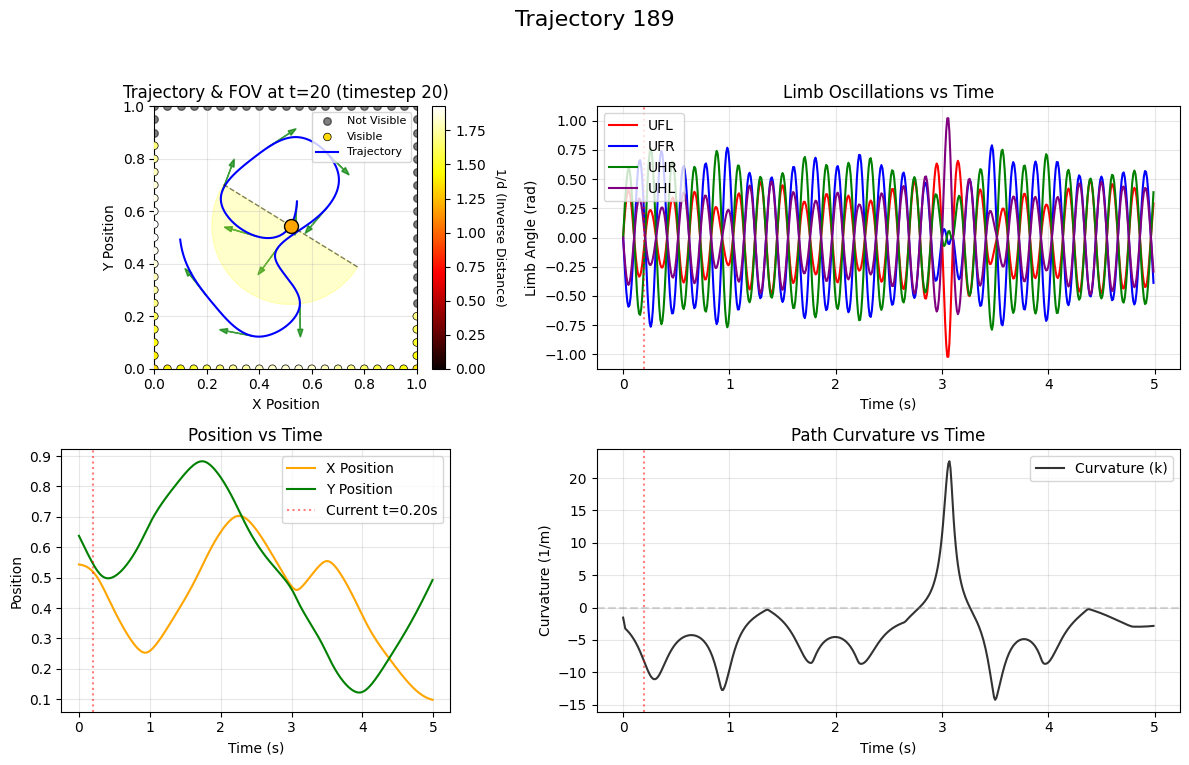

  Visible landmarks at t=20: 42/80 (52.5%)


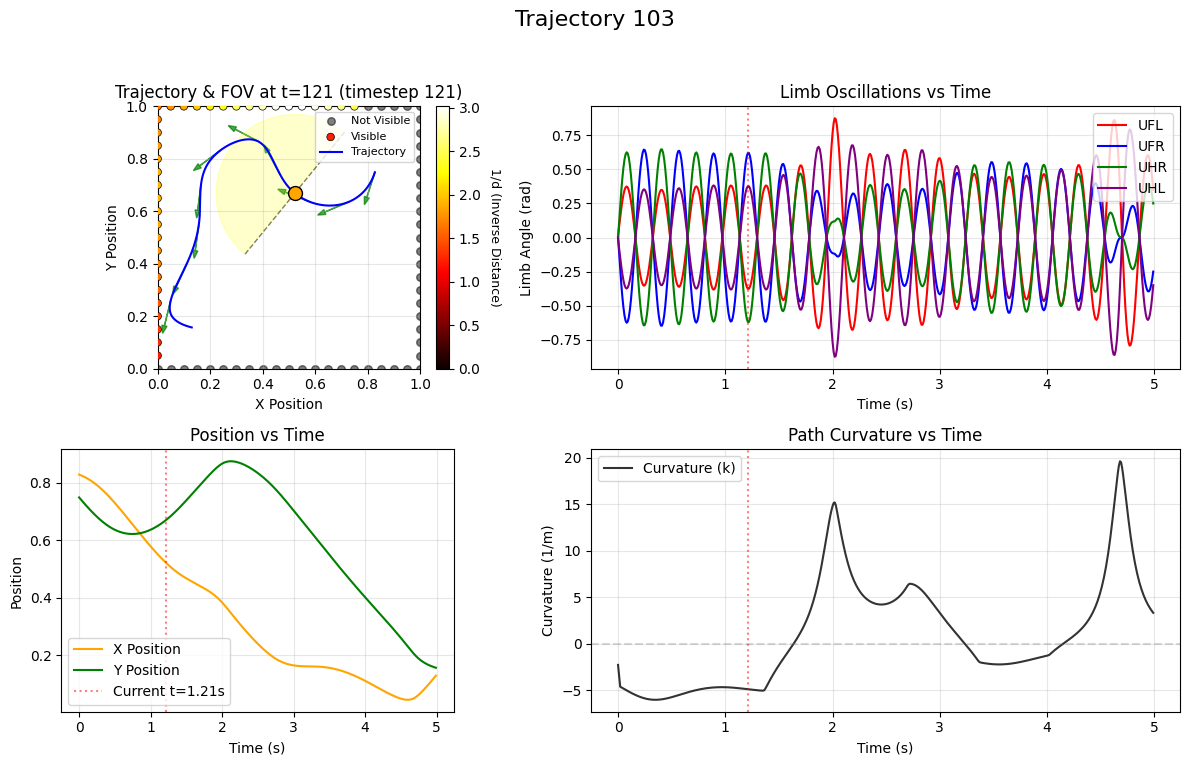

  Visible landmarks at t=121: 35/80 (43.8%)


In [11]:
plot_data(train_inputs=train_inputs, train_outputs=train_outputs, time_series=time_series)

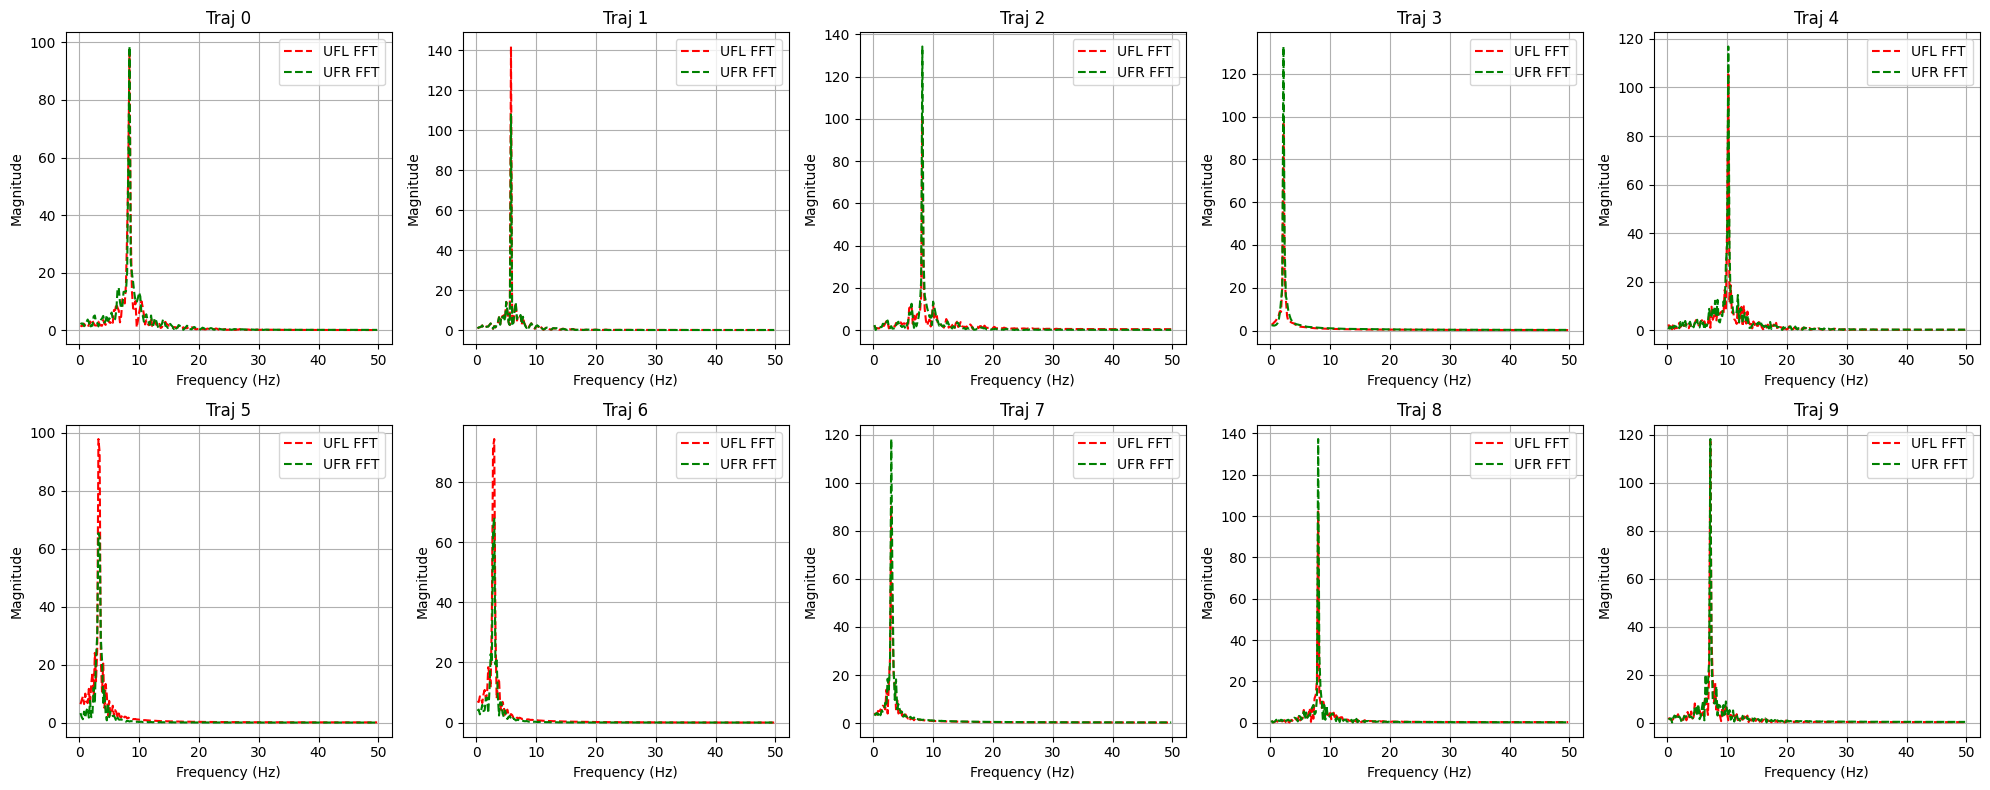

In [12]:
# FFTs of data to adjust oscillatory frequencies

    
# Create a grid of subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, ax in enumerate(axes.flatten()):
    traj_index = i
    limb_osc = train_inputs["limb_osc"][traj_index]
    UFL_traj, UFR_traj, UHR_traj, UHL_traj = limb_osc.T
    x_position = train_outputs["pos"][traj_index, :, 0].flatten()
    y_position = train_outputs["pos"][traj_index, :, 1].flatten()

    fft_ufl = fft(UFL_traj)
    fft_ufr = fft(UFR_traj)
    fft_uhr = fft(UHR_traj)
    fft_uhl = fft(UHL_traj)
    fft_x = fft(x_position)
    fft_y = fft(y_position)

    n = len(x_position)
    frequencies = fftfreq(n, d=0.01)

    magnitude_x = np.abs(fft_x)
    magnitude_y = np.abs(fft_y)

    # Removing the zero frequency component for better visualization
    #ax.plot(frequencies[1:n // 2], magnitude_x[1:n // 2], label='X FFT', color='blue')
    #ax.plot(frequencies[1:n // 2], magnitude_y[1:n // 2], label='Y FFT', color='orange')

    ax.plot(frequencies[1:n // 2], np.abs(fft_ufl)[1:n // 2], label='UFL FFT', color='red', linestyle='--')
    ax.plot(frequencies[1:n // 2], np.abs(fft_ufr)[1:n // 2], label='UFR FFT', color='green', linestyle='--')

    ax.set_title(f'Traj {traj_index}')
    #ax.set_xlim(0, 2)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude')
    #ax.set_ylim(0, 10)
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

In [13]:
# Training Data into Network

X = np.concatenate((train_inputs["visual_cue"], train_inputs["limb_osc"]), axis=2)
Y = train_outputs["pos"]

print(X.shape, Y.shape)

(500, 500, 84) (500, 500, 2)


In [14]:
# Test Data into Network

"""X_test = np.concatenate((test_inputs["visual_cue"], test_inputs["limb_osc"]), axis=2)
Y_test = test_outputs["pos"]
print(X_test.shape, Y_test.shape)"""

'X_test = np.concatenate((test_inputs["visual_cue"], test_inputs["limb_osc"]), axis=2)\nY_test = test_outputs["pos"]\nprint(X_test.shape, Y_test.shape)'

#### Network Training - Pos Prediction

In [15]:
#Hopf Oscillator

def real_cal(r, phi):
    return r * torch.cos(phi)

def imag_cal(r, phi):
    return r * torch.sin(phi)


def oscillator_loop(X_r, X_i, omegas, num_steps, dt=0.01, input_scaler=5):
    
    """
    X_r, X_i: real and imaginary parts of input signal [batch, time, units]
    omegas: angular frequencies of oscillators [1, units]
    num_steps: number of time steps
    """

    batch_size, _, units = X_r.shape
    

    # amplitude and phase initialisation
    r_t = torch.ones((batch_size, units), device=X_r.device)
    phis = torch.zeros((batch_size, units), device=X_r.device)

    #r_t = 0.9 + 0.2 * torch.rand((batch_size, units), device=X_r.device)
    #phis = (2 * math.pi) * torch.rand((batch_size, units), device=X_r.device) - math.pi

    r_list, phi_list = [], []

    for t in range(num_steps):
        # input at current time step
        input_r = input_scaler * X_r[:, t, :] * torch.cos(phis)
        input_phi = input_scaler * X_i[:, t, :] * torch.sin(phis)

        # Hopf oscillator update equations
        r_t = r_t + ((1 - r_t**2) * r_t + input_r) * dt
        phis = phis + (omegas - input_phi) * dt

        r_list.append(r_t.unsqueeze(1))   # keep time dimension
        phi_list.append(phis.unsqueeze(1))

    # Stack time axis -> shape [batch, time, units]
    r_arr = torch.cat(r_list, dim=1)
    phi_arr = torch.cat(phi_list, dim=1)
    return r_arr, phi_arr



class Hopf(nn.Module):
    def __init__(self, units, num_steps, min_f=0.1, max_f=10.1):
        super(Hopf, self).__init__()
        self.units = units
        self.num_steps = num_steps

        # Frequencies equally spaced between min_f and max_f
        omegas = torch.linspace(min_f, max_f, units) * (2 * math.pi)
        self.register_buffer('omegas', omegas.unsqueeze(0))  # [1, units]

    def forward(self, z_complex):
        """
        z_complex: complex input tensor [batch, time, units]
        """
        X_r = z_complex.real
        X_i = z_complex.imag

        r, phi = oscillator_loop(X_r, X_i, self.omegas, self.num_steps)

        z_real = real_cal(r, phi)
        z_imag = imag_cal(r, phi)
        return torch.complex(z_real, z_imag)


In [16]:
# Helper network modules
   

class TimeDistributed(nn.Module):
    """
    Applies a module (e.g. Linear, Conv, etc.) to each time step independently.
    Input shape:  [batch, time, features]
    Output shape: [batch, time, output_features]
    """
    def __init__(self, module):
        super(TimeDistributed, self).__init__()
        self.module = module

    def forward(self, x):
        # If input is already 2D (no time dimension)
        if len(x.size()) <= 2:
            return self.module(x)

        batch_size, time_steps, features = x.size()
        x_reshaped = x.contiguous().view(batch_size * time_steps, features)
        y = self.module(x_reshaped)
        # Restore shape
        y = y.contiguous().view(batch_size, time_steps, -1)
        return y

class ComplexLeakyReLU(nn.Module):
    def __init__(self, negative_slope=0.1):
        super(ComplexLeakyReLU, self).__init__()
        self.negative_slope = negative_slope
    
    def forward(self, z):
        # Apply LeakyReLU separately to real and imaginary parts
        real = torch.nn.functional.leaky_relu(z.real, negative_slope=self.negative_slope)
        imag = torch.nn.functional.leaky_relu(z.imag, negative_slope=self.negative_slope)
        return torch.complex(real, imag)

In [17]:
class DONN(nn.Module):
    def __init__(self, units, duration):
        super(DONN, self).__init__()

        # -----------------------------
        # Complex Dense + Hopf layers
        # -----------------------------
        self.d1 = nn.Sequential(
            TimeDistributed(ComplexLinear(X.shape[-1], units)),
            ComplexLeakyReLU(),
            
        )
        self.osc1 = Hopf(units, num_steps=duration, min_f=1, max_f=10)

        self.d2 = nn.Sequential(
            TimeDistributed(ComplexLinear(units, units)),
            ComplexLeakyReLU(),
            
        )
        self.osc2 = Hopf(units, num_steps=duration, min_f=4, max_f=8)

        self.d3 = nn.Sequential(
            TimeDistributed(ComplexLinear(units, units)),
            ComplexLeakyReLU(),
            
        )
        self.osc3 = Hopf(units, num_steps=duration, min_f=0.1, max_f=5)

        self.d4 = nn.Sequential(
            TimeDistributed(nn.Linear(units * 2, units)),
            nn.LeakyReLU(),
            
        )

        # -----------------------------
        # Real-valued output heads
        # -----------------------------
        self.pos_out = nn.Sequential(
            nn.Linear(units, 2),  # for (x, y)
            nn.Sigmoid()
        )


        # For storing intermediate outputs
        self.d1_out = None
        self.osc1_out = None
        self.d2_out = None
        self.osc2_out = None
        self.d3_out = None
        self.osc3_out = None

        

    def forward(self, X):
        """
        X: [batch, time, units] real input signal
        """

        # Input Convert to complex
        X_c = torch.complex(X, torch.zeros_like(X))

        # 3 pairs of sequential complex transformations + Hopf oscillations

        d1 = self.d1(X_c)
        self.d1_out = d1
        z1 = self.osc1(d1)
        self.z1 = z1

        d2 = self.d2(z1)
        self.d2_out = d2
        z2 = self.osc2(d2)
        self.z2 = z2

        d3 = self.d3(z2)
        self.d3_out = d3
        z3 = self.osc3(d3)
        self.z3 = z3

        #z3_abs = torch.abs(z3)
        
        #Concatenate real and imag before final dense layer
        z3_concat = torch.cat([z3.real, z3.imag], dim=-1)
        d4 = self.d4(z3_concat)
        
        
        # Position output (sigmoid) → (x, y)
        
        pos_out = self.pos_out(d4)
        
    
        return {"pos": pos_out}
        #return {"pos": pos_out, "hd": hd_out}
        

In [18]:
# ========================GPU Usage========================
# Template:
'''
Instantiate the model
Define primary device
Move model to primary device
Wrap things like DataParallel or DDP if needed
'''

# To use any GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#To use a specific GPU
#device = torch.device("cuda:0")
#model.to(device)

# To use all GPUs in parallel
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# model = model.to(device)
# if torch.cuda.device_count() > 1:
#     print("Using", torch.cuda.device_count(), "GPUs")
#     model = nn.DataParallel(model)

# To use a specific SET of GPUs
# device_ids = [1, 2, 3]
# device = torch.device(f'cuda:{device_ids[0]}')
# model = model.to(f'cuda:{device_ids[0]}')
# model = nn.DataParallel(model, device_ids=device_ids)

# Distributed Data Parallel (DDP)
# For large processes
# Code modularization needed for this


# ========================GPU Usage========================


In [33]:
# Hyperparameters
units = 50
learning_rate = 0.001
batch_size = 20
#epochs = 300

duration = total_time_steps  # same as in TF version
#duration = 500

model = DONN(units=units, duration=duration).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    # verbose=True
)
mse_loss = nn.MSELoss()
huber_loss = nn.HuberLoss()

#Print the GPUs being used
print("Model is running on:", next(model.parameters()).device)


Model is running on: cpu


In [34]:
#print(X.shape, Y.shape, X_test.shape, Y_test.shape)

In [35]:
# Convert NumPy arrays to PyTorch tensors
X_tensor = torch.tensor(X[:, :, :], dtype=torch.float32)
Y_pos_tensor = torch.tensor(Y[:, :, :], dtype=torch.float32)

# Combine into one dataset
dataset = TensorDataset(X_tensor, Y_pos_tensor)

# 80-20 train-validation split
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

print("Train data shape:", X_tensor.shape, Y_pos_tensor.shape)

weights_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/zagent_data/weights/2026-06-26_2d_v4_pos_current_v4_100.pth"


Train data shape: torch.Size([500, 500, 84]) torch.Size([500, 500, 2])


In [36]:
def training_loop(model, optimizer, scheduler, train_loader, val_loader, start_epoch, end_epoch, pos_loss_weight, hd_loss_weight, save_every=100, save_path=weights_path, early_stop_patience=30, use_scheduler=False, use_early_stopping=False):

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    
    prev_lr = optimizer.param_groups[0]['lr']

    for epoch in range(start_epoch, end_epoch):
        model.train()
        total_loss = 0.0
        
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{end_epoch}", leave=False)
        
        for X_batch, Y_pos_batch in batch_bar:
            X_batch, Y_pos_batch = X_batch.to(device), Y_pos_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)

            pos_pred = predictions["pos"]
            #hd_pred = predictions["hd"]

            # Compute combined loss
            loss_pos = huber_loss(pos_pred, Y_pos_batch)
            loss = pos_loss_weight * loss_pos
            

            loss.backward()
            #nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for X_val, Y_pos_val in val_loader:
                X_val, Y_pos_val = X_val.to(device), Y_pos_val.to(device)
                predictions = model(X_val)
                pos_pred = predictions["pos"]
                #hd_pred = predictions["hd"]
                #val_loss += (pos_loss_weight * mse_loss(pos_pred, Y_pos_val) + hd_loss_weight * hd_vector_loss(hd_pred, Y_hd_val)).item()
                val_loss += (pos_loss_weight * huber_loss(pos_pred, Y_pos_val)).item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if use_scheduler and scheduler is not None:
            scheduler.step(avg_val_loss)
            # explicit logging using new API
            last_lr = scheduler.get_last_lr()  # returns list per param_group
            if (epoch + 1) % 10 == 0 or epoch == 0:
                tqdm.write(f"LR after scheduler step: {last_lr}")
                
            
        # Early Stopping Check

        current_lr = optimizer.param_groups[0]['lr']

        if use_early_stopping:
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
            elif current_lr < prev_lr:
                patience_counter = 0
            else:
                patience_counter += 1
            prev_lr = current_lr

            if patience_counter >= early_stop_patience:
                tqdm.write("Early stopping triggered")
                break

        #if (epoch + 1) % 10 == 0 or epoch == 0:
            
        tqdm.write(f"Epoch [{epoch+1}/{end_epoch}] | Train Loss: {total_loss/len(train_loader):.6f} | Val Loss: {val_loss/len(val_loader):.6f}")

        
        # Save checkpoint
        if (epoch + 1) % save_every == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
            }, f"{save_path}{today}_{file_name}_{epoch+1}.pth")
            tqdm.write(f"Saved checkpoint at epoch {epoch+1}")    

    return model, optimizer, scheduler, epoch+1, train_losses, val_losses

In [37]:
resume_training = False
total_epochs = 200

In [38]:
# If resuming training

if resume_training:
    checkpoint_path = f"{weights_path}{today}_{file_name}_{total_epochs}.pth"

    # Load saved model and optimizer
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"]
    print(f"Resumed from epoch {start_epoch}")

else:
    start_epoch = 0


In [39]:

"""pos_loss_weight = 1
hd_loss_weight = 0

end_epoch = start_epoch + total_epochs

model, optimizer, scheduler, last_epoch, train_losses, val_losses = training_loop(
    model, optimizer, scheduler, train_loader, val_loader,
    start_epoch, end_epoch,
    pos_loss_weight, hd_loss_weight)"""



'pos_loss_weight = 1\nhd_loss_weight = 0\n\nend_epoch = start_epoch + total_epochs\n\nmodel, optimizer, scheduler, last_epoch, train_losses, val_losses = training_loop(\n    model, optimizer, scheduler, train_loader, val_loader,\n    start_epoch, end_epoch,\n    pos_loss_weight, hd_loss_weight)'

In [40]:
"""print("Final Loss is:", train_losses[-1])
print("Validation Loss is:", val_losses[-1])"""

'print("Final Loss is:", train_losses[-1])\nprint("Validation Loss is:", val_losses[-1])'

In [41]:
"""plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()"""

"plt.plot(train_losses, label='Train Loss')\nplt.plot(val_losses, label='Validation Loss')\n\nplt.xlabel('Epochs')\nplt.ylabel('Loss')\nplt.title('Training and Validation Loss over Epochs')\nplt.legend()\nplt.show()"

In [42]:
# Saving weights 
"""

torch.save({
    'epoch': end_epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses
}, f"{weights_path}{today}_{file_name}_{total_epochs}")

print("Weights saved successfully at:", f"{weights_path}{today}_{file_name}_{total_epochs}")"""

'\n\ntorch.save({\n    \'epoch\': end_epoch,\n    \'model_state_dict\': model.state_dict(),\n    \'optimizer_state_dict\': optimizer.state_dict(),\n    \'train_losses\': train_losses,\n    \'val_losses\': val_losses\n}, f"{weights_path}{today}_{file_name}_{total_epochs}")\n\nprint("Weights saved successfully at:", f"{weights_path}{today}_{file_name}_{total_epochs}")'

In [43]:
print(file_name)

2d_v4_pos_current_v4


In [45]:
# Loading model for prediction (no training)

today = "26th_jun_2026"

model = DONN(units=units, duration=total_time_steps).to(device)

weights_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/"

weights_file = "2026-07-09_2d_grid_training_secured_v2_100_final.pth"

checkpoint = torch.load(
    os.path.join(weights_path, weights_file),
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.load_optimizer_state_dict = checkpoint["optimizer_state_dict"]

print("Model loaded for inference (no training).")

Model loaded for inference (no training).


In [46]:
print("State Dictionary:", checkpoint["model_state_dict"].keys())

State Dictionary: odict_keys(['d1.0.module.fc_r.weight', 'd1.0.module.fc_r.bias', 'd1.0.module.fc_i.weight', 'd1.0.module.fc_i.bias', 'osc1.omegas', 'd2.0.module.fc_r.weight', 'd2.0.module.fc_r.bias', 'd2.0.module.fc_i.weight', 'd2.0.module.fc_i.bias', 'osc2.omegas', 'd3.0.module.fc_r.weight', 'd3.0.module.fc_r.bias', 'd3.0.module.fc_i.weight', 'd3.0.module.fc_i.bias', 'osc3.omegas', 'd4.0.module.weight', 'd4.0.module.bias', 'pos_out.0.weight', 'pos_out.0.bias'])


In [47]:
# =====================================================
# Extract intermediate activations on TRAINING DATA
# =====================================================

intermediate_outputs = {}

def get_activation(name):
    def hook(module, input, output):
        intermediate_outputs[name] = output.detach()
    return hook

# Register hooks
hook_d1 = model.d1.register_forward_hook(get_activation("d1"))
hook_d2 = model.d2.register_forward_hook(get_activation("d2"))
hook_d3 = model.d3.register_forward_hook(get_activation("d3"))
hook_d4 = model.d4.register_forward_hook(get_activation("d4"))

hook_z1 = model.osc1.register_forward_hook(get_activation("z1"))
hook_z2 = model.osc2.register_forward_hook(get_activation("z2"))
hook_z3 = model.osc3.register_forward_hook(get_activation("z3"))

# Run model on TRAINING data
model.eval()

with torch.no_grad():
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    outputs = model(X_tensor)

# Extract activations
d1_out = intermediate_outputs["d1"].cpu().numpy()
d2_out = intermediate_outputs["d2"].cpu().numpy()
d3_out = intermediate_outputs["d3"].cpu().numpy()
d4_out = intermediate_outputs["d4"].cpu().numpy()

z1_out = intermediate_outputs["z1"].cpu().numpy()
z2_out = intermediate_outputs["z2"].cpu().numpy()
z3_out = intermediate_outputs["z3"].cpu().numpy()

pos_pred = outputs["pos"].cpu().numpy()

print("=" * 60)
print("TRAINING ACTIVATIONS")
print("=" * 60)
print("d1:", d1_out.shape)
print("z1:", z1_out.shape)
print("d2:", d2_out.shape)
print("z2:", z2_out.shape)
print("d3:", d3_out.shape)
print("z3:", z3_out.shape)
print("d4:", d4_out.shape)
print("prediction:", pos_pred.shape)

# Remove hooks
hook_d1.remove()
hook_d2.remove()
hook_d3.remove()
hook_d4.remove()

hook_z1.remove()
hook_z2.remove()
hook_z3.remove()

TRAINING ACTIVATIONS
d1: (500, 500, 50)
z1: (500, 500, 50)
d2: (500, 500, 50)
z2: (500, 500, 50)
d3: (500, 500, 50)
z3: (500, 500, 50)
d4: (500, 500, 50)
prediction: (500, 500, 2)


In [48]:
def plot_predictions(inputs, outputs, predictions, time_series, fov=np.pi, fov_radius=0.3):
    for i in range(5):
        #traj_index = np.random.randint(0, len(inputs["visual_cue"]))
        traj_index = i
        landmarks = build_wall_landmarks()
        
        # Get data for current trajectory
        coordinate_data = outputs["pos"][traj_index]
        hd_vector_data = outputs["hd_vec"][traj_index]
        x_coords = coordinate_data[:, 0]
        y_coords = coordinate_data[:, 1]
        cos_thetas = hd_vector_data[:, 0]
        sin_thetas = hd_vector_data[:, 1]
        limb_oscillations = inputs["limb_osc"][traj_index]
        UFL_traj, UFR_traj, UHR_traj, UHL_traj = limb_oscillations.T
        k_traj = inputs["curvature"][traj_index]
        
        # Get visual cue data for current trajectory
        # Shape: [T, 80] where 80 landmarks, each has inverse distance (1/d)
        visual_cue = inputs["visual_cue"][traj_index]  # (T, 80)
        
        # Create a 2x2 grid
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [1, 1.5]})
        fig.suptitle(f"Trajectory {traj_index+1}", fontsize=16)
        

        # --- Top-left: Trajectory in grid with FOV ---
        # Pick a random timestep to show FOV
        t = np.random.randint(0, len(x_coords))
        xt, yt = x_coords[t], y_coords[t]
        head_vec = np.array([cos_thetas[t], sin_thetas[t]])
        
        # Extract visibility from visual cue at time t
        # visual_cue_inverse_dist[t, :] contains inverse distances for all 80 landmarks
        # If inverse distance > 0, landmark is visible
        inverse_dists_at_t = visual_cue[t, :]  # (80,)
        visible = inverse_dists_at_t > 0
        
        # Plot landmarks
        axes[0, 0].scatter(landmarks[~visible, 0], landmarks[~visible, 1],
                          color='black', s=30, label='Not Visible', alpha=0.5)
        
        # For visible landmarks, use color to indicate inverse distance (fixed size)
        if np.any(visible):
            vis_inv_dists = inverse_dists_at_t[visible]
            scatter = axes[0, 0].scatter(landmarks[visible, 0], landmarks[visible, 1],
                              c=vis_inv_dists, s=30, cmap='hot', 
                              label='Visible', zorder=5, edgecolors='black', linewidths=0.5,
                              vmin=0, vmax=np.max(vis_inv_dists))
            # Add colorbar for inverse distance
            cbar = plt.colorbar(scatter, ax=axes[0, 0], fraction=0.046, pad=0.04)
            cbar.set_label('1/d (Inverse Distance)', rotation=270, labelpad=15, fontsize=9)
        
        # Plot trajectory
        axes[0, 0].plot(x_coords, y_coords, color='blue', label='Trajectory', linewidth=1.5)
        axes[0, 0].plot(predictions[traj_index, :, 0], predictions[traj_index, :, 1], color='green')
        
        # Plot head direction arrows
        for j in range(0, len(x_coords), 50):  # every 50 steps
            axes[0, 0].arrow(x_coords[j], y_coords[j],
                    0.1 * cos_thetas[j], 0.1 * sin_thetas[j],
                    color='green', head_width=0.02, alpha=0.7)
            
        # Plot agent and FOV cone
        axes[0, 0].scatter(xt, yt, color='orange', s=100, zorder=10, edgecolors='black', linewidths=1)
        angle = math.atan2(head_vec[1], head_vec[0])
        left_angle = angle - fov/2
        right_angle = angle + fov/2
        
        # FOV cone edges
        axes[0, 0].plot([xt, xt + fov_radius * math.cos(left_angle)],
                       [yt, yt + fov_radius * math.sin(left_angle)],
                       'k--', alpha=0.5, linewidth=1)
        axes[0, 0].plot([xt, xt + fov_radius * math.cos(right_angle)],
                       [yt, yt + fov_radius * math.sin(right_angle)],
                       'k--', alpha=0.5, linewidth=1)
        
        # Shaded FOV cone
        theta = np.linspace(left_angle, right_angle, 30)
        axes[0, 0].fill(xt + fov_radius * np.cos(theta),
                       yt + fov_radius * np.sin(theta),
                       color='yellow', alpha=0.2)
        
        axes[0, 0].set_title(f'Trajectory & FOV at t={t} (timestep {t})')
        axes[0, 0].set_xlabel('X Position')
        axes[0, 0].set_ylabel('Y Position')
        axes[0, 0].set_xlim(0, 1)
        axes[0, 0].set_ylim(0, 1)
        axes[0, 0].grid(alpha=0.3)
        axes[0, 0].legend(loc='upper right', fontsize=8)
        axes[0, 0].set_aspect('equal')

        # --- Bottom-left: Position vs time ---
        axes[1, 0].plot(time_series[:], x_coords, label='X Position', color='orange', linewidth=1.5)
        axes[1, 0].plot(time_series[:], y_coords, label='Y Position', color='green', linewidth=1.5)
        axes[1, 0].plot(time_series[:], predictions[traj_index, :, 0], label='Predicted X', color='orange', linestyle='--', linewidth=1.5)
        axes[1, 0].plot(time_series[:], predictions[traj_index, :, 1], label='Predicted Y', color='green', linestyle='--', linewidth=1.5)
        
        axes[1, 0].axvline(time_series[t], color='red', linestyle=':', alpha=0.5, label=f'Current t={time_series[t]:.2f}s')
        axes[1, 0].set_title('Position vs Time')
        axes[1, 0].set_xlabel('Time (s)')
        axes[1, 0].set_ylabel('Position')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

        # --- Right column (span): Limb oscillations ---
        ax_right = axes[0, 1]
        ax_right.plot(time_series, UFL_traj[:len(time_series)], label='UFL', color='red', linewidth=1.5)
        ax_right.plot(time_series, UFR_traj[:len(time_series)], label='UFR', color='blue', linewidth=1.5)
        ax_right.plot(time_series, UHR_traj[:len(time_series)], label='UHR', color='green', linewidth=1.5)
        ax_right.plot(time_series, UHL_traj[:len(time_series)], label='UHL', color='purple', linewidth=1.5)
        ax_right.axvline(time_series[t], color='red', linestyle=':', alpha=0.5)
        
        ax_right.set_title(f'Limb Oscillations vs Time')
        ax_right.set_xlabel('Time (s)')
        ax_right.set_ylabel('Limb Angle (rad)')
        ax_right.legend()
        ax_right.grid(alpha=0.3)

        # --- Bottom-right: Curvature ---
        ax_bottom_right = axes[1, 1]
        ax_bottom_right.plot(time_series, k_traj[:len(time_series)], 
                           label='Curvature (k)', color='black', linestyle='-', linewidth=1.5, alpha=0.8)
        ax_bottom_right.axvline(time_series[t], color='red', linestyle=':', alpha=0.5)
        ax_bottom_right.axhline(0, color='gray', linestyle='--', alpha=0.3)
        ax_bottom_right.set_ylabel('Curvature (1/m)')
        ax_bottom_right.set_xlabel('Time (s)')
        ax_bottom_right.set_title('Path Curvature vs Time')
        ax_bottom_right.legend()
        ax_bottom_right.grid(alpha=0.3)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
        # Print visibility statistics
        num_visible = np.sum(visible)
        print(f"  Visible landmarks at t={t}: {num_visible}/80 ({num_visible/80*100:.1f}%)")

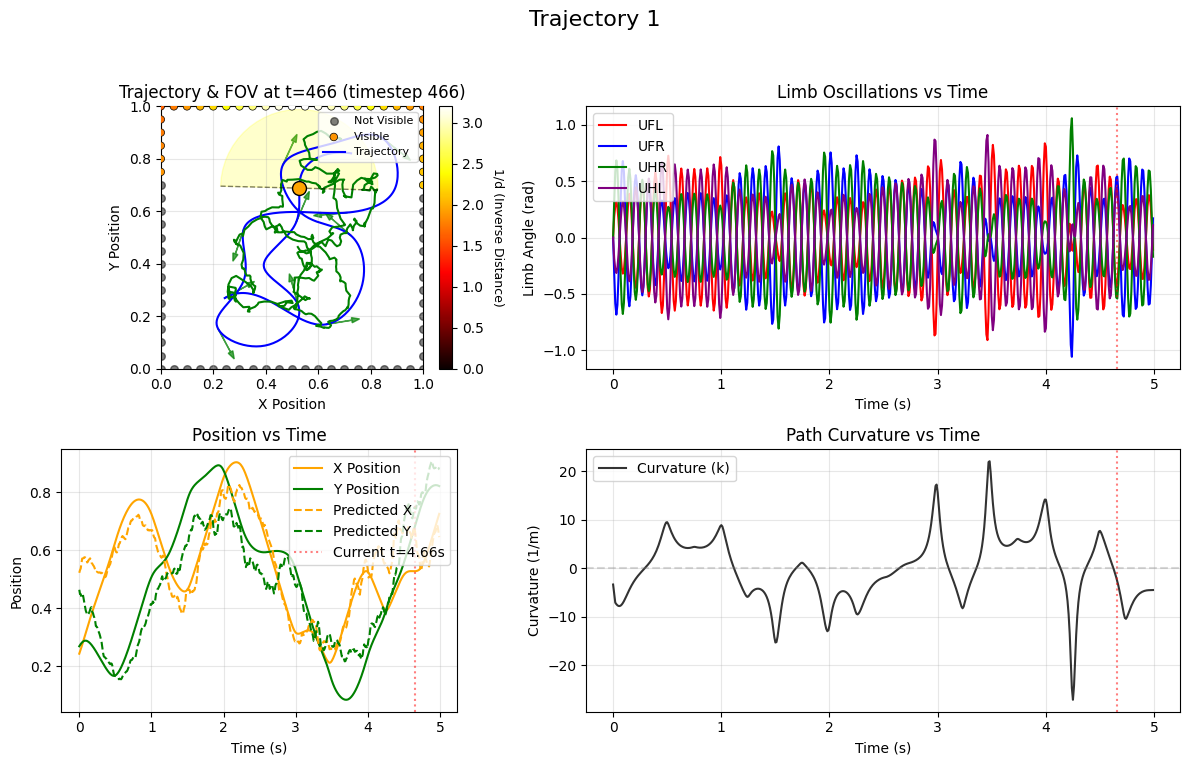

  Visible landmarks at t=466: 32/80 (40.0%)


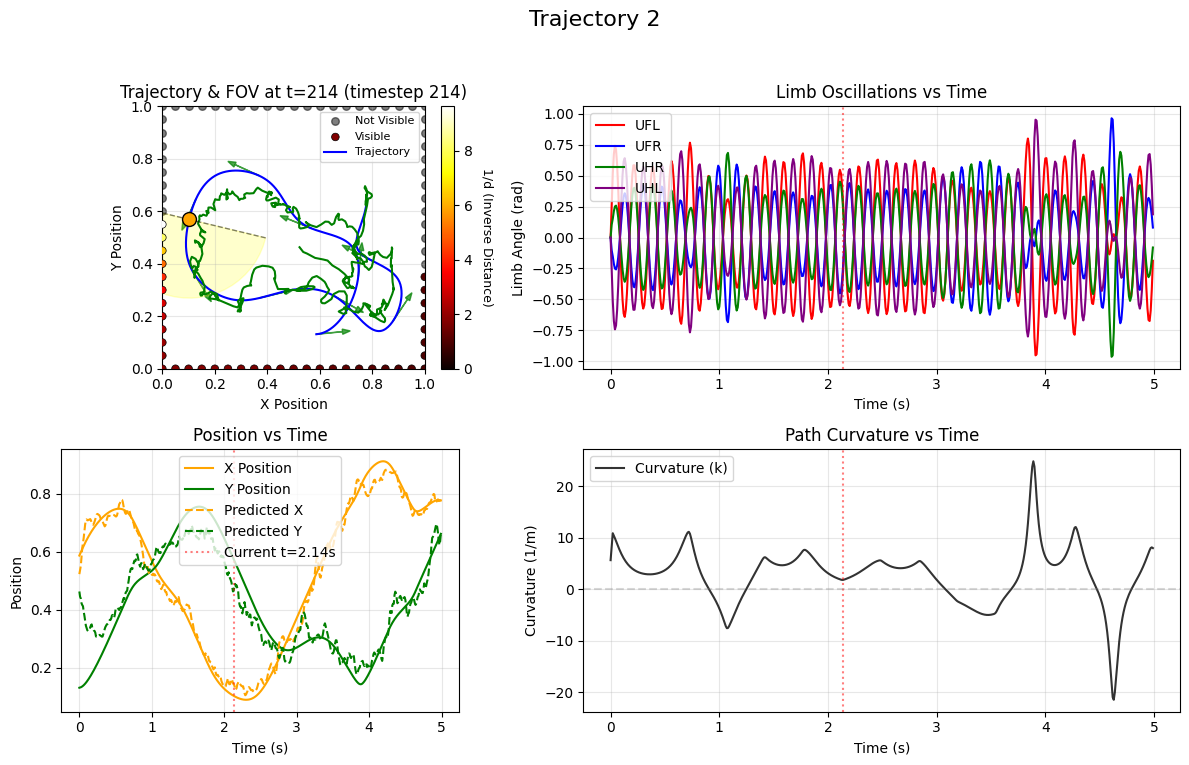

  Visible landmarks at t=214: 39/80 (48.8%)


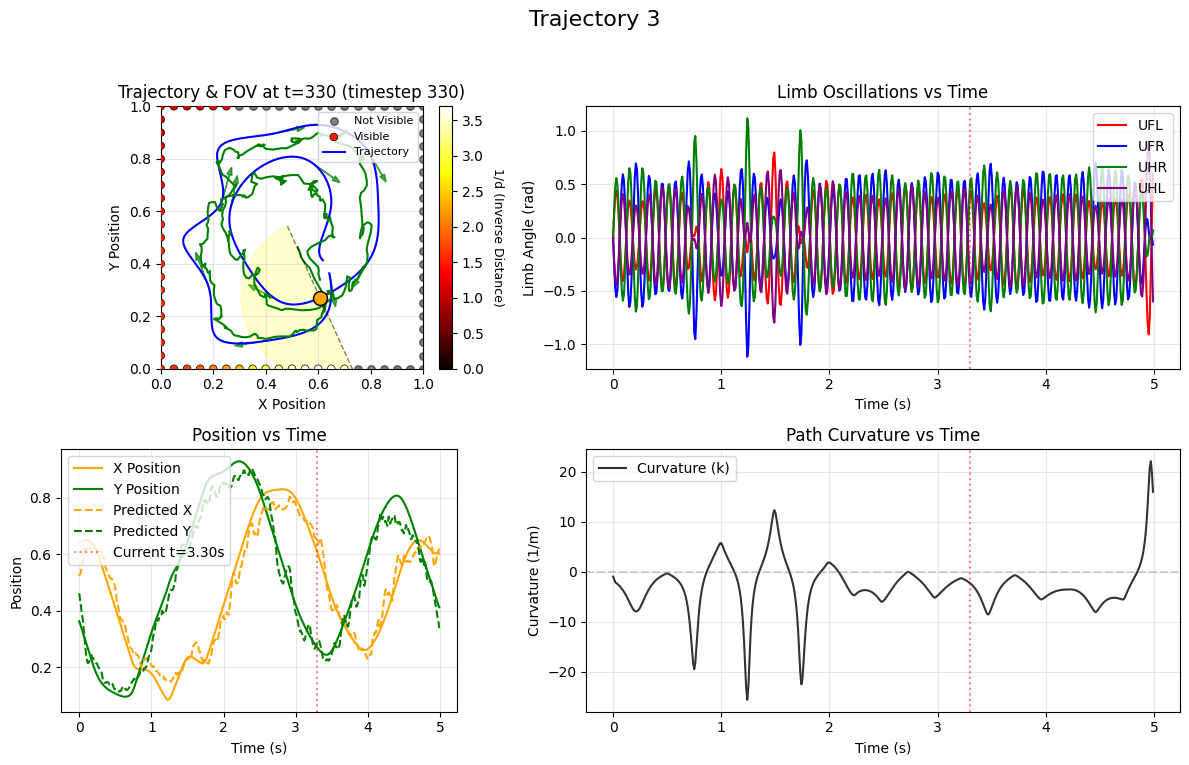

  Visible landmarks at t=330: 40/80 (50.0%)


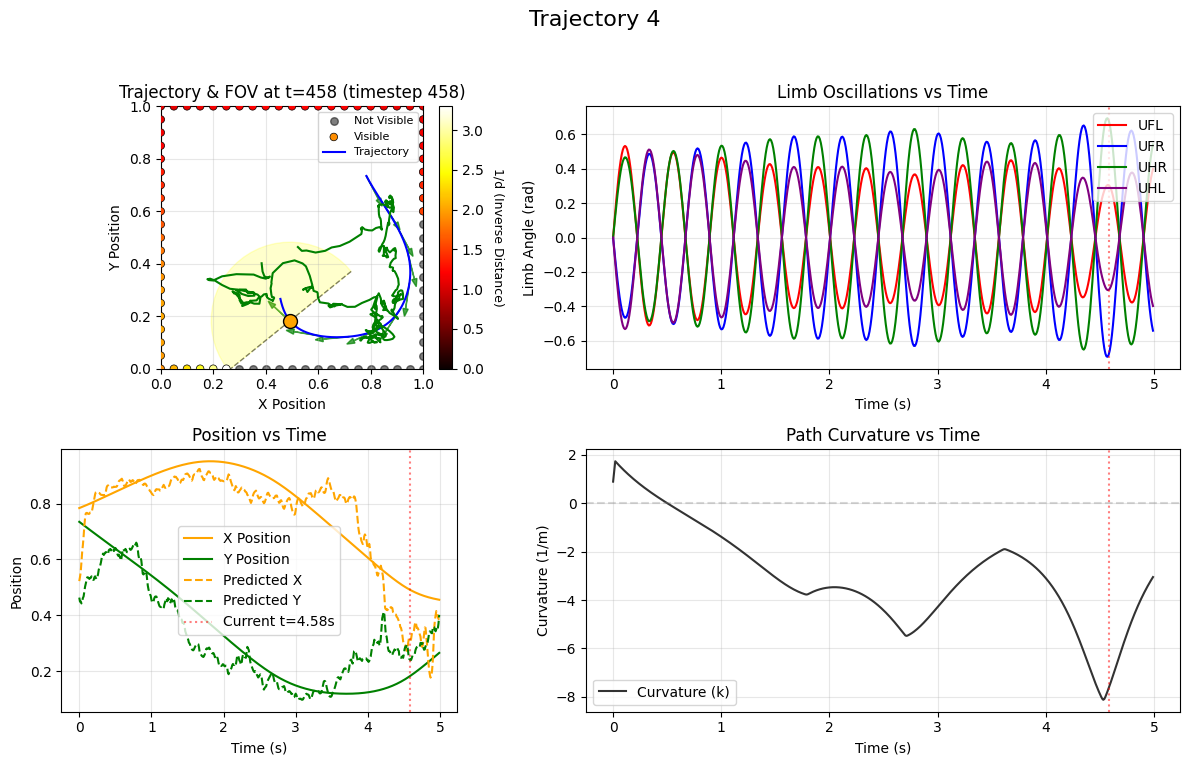

  Visible landmarks at t=458: 54/80 (67.5%)


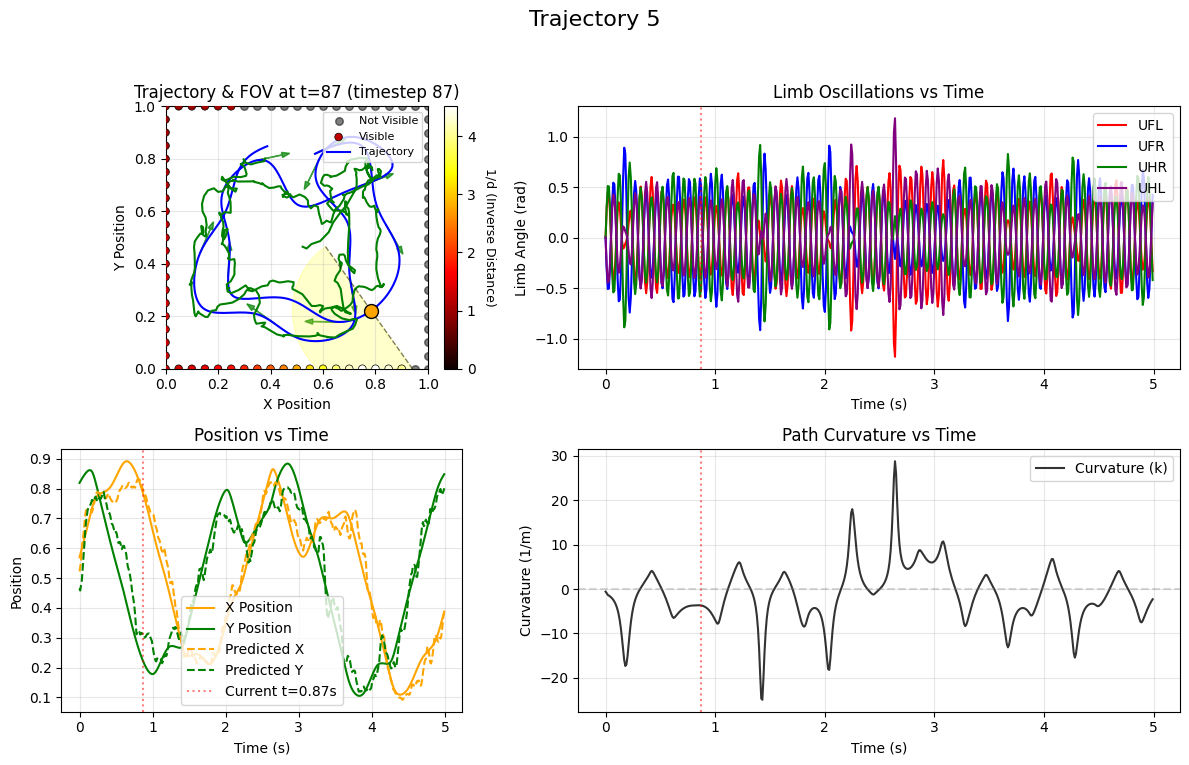

  Visible landmarks at t=87: 44/80 (55.0%)


In [49]:
plot_predictions(
    inputs=train_inputs,
    outputs=train_outputs,
    predictions=pos_pred,
    time_series=time_series
)

In [50]:
true_positions = torch.tensor(train_trajectory_data[:, :, :2], dtype=torch.float32)
predicted_positions = torch.tensor(pos_pred, dtype=torch.float32)

mse = torch.mean((true_positions - predicted_positions) ** 2)
rmse = torch.sqrt(mse)
mae = torch.mean(torch.abs(true_positions - predicted_positions))

print(f"MSE  : {mse.item():.6f}")
print(f"RMSE : {rmse.item():.6f}")
print(f"MAE  : {mae.item():.6f}")

MSE  : 0.004929
RMSE : 0.070207
MAE  : 0.050423


In [51]:
import os
import pickle

save_folder = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells"
os.makedirs(save_folder, exist_ok=True)

save_file = "50-neurons-2D-traj-results-training.pkl"
save_path = os.path.join(save_folder, save_file)

results = {
    "time": time_series,

    "ground_truth": Y,
    "prediction": pos_pred,

    "d1": d1_out,
    "z1": z1_out,

    "d2": d2_out,
    "z2": z2_out,

    "d3": d3_out,
    "z3": z3_out,

    "d4": d4_out,
}

with open(save_path, "wb") as f:
    pickle.dump(results, f)

print(f"Saved successfully to:\n{save_path}")

print("\nContents:")
for key, value in results.items():
    if hasattr(value, "shape"):
        print(f"{key:15s} {value.shape}")
    else:
        print(f"{key:15s} {len(value)}")

Saved successfully to:
/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/50-neurons-2D-traj-results-training.pkl

Contents:
time            (500,)
ground_truth    (500, 500, 2)
prediction      (500, 500, 2)
d1              (500, 500, 50)
z1              (500, 500, 50)
d2              (500, 500, 50)
z2              (500, 500, 50)
d3              (500, 500, 50)
z3              (500, 500, 50)
d4              (500, 500, 50)
